In [27]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
# Machine Learning
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [28]:
# Load Titanic Dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (891, 12)

Columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Types:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [30]:
# Missing values count

missing_values = df.isnull().sum()

print("Missing Values:\n")
print(missing_values)

Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [31]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000


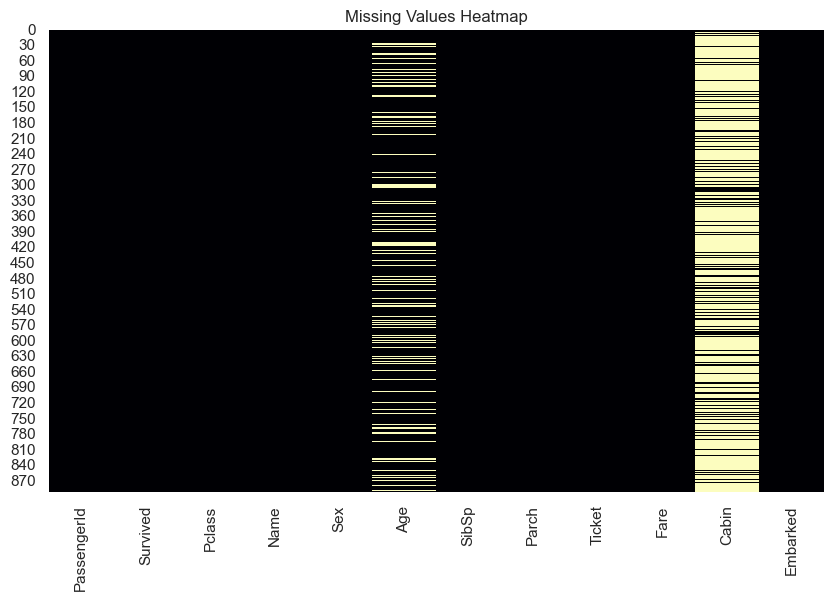

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap='magma')

plt.title("Missing Values Heatmap")
plt.show()

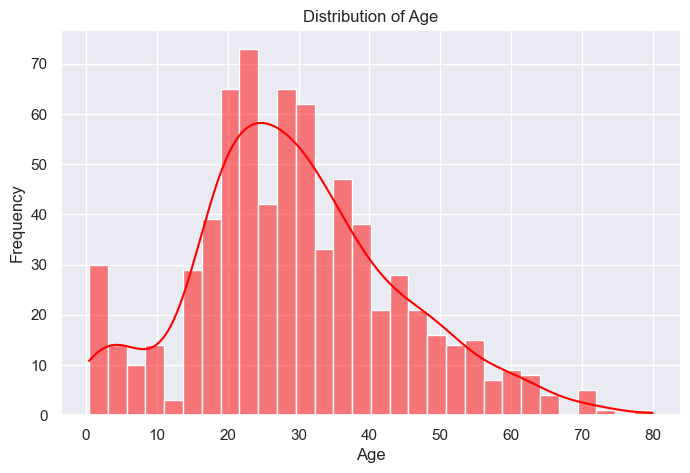

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True,color="Red")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [34]:
# Select rows where Age exists

age_data = df[df['Age'].notnull()].copy()

# Save original Age values
original_age = age_data['Age'].copy()

# Randomly select 20% rows for masking

np.random.seed(42)

mask_indices = age_data.sample(frac=0.2).index

# Create masked dataset
age_data.loc[mask_indices, 'Age'] = np.nan

print("Number of artificially masked values:", len(mask_indices))

Number of artificially masked values: 143


In [35]:
# Copy dataset
mean_imputed = age_data.copy()

# Calculate mean
mean_age = mean_imputed['Age'].mean()

# Fill missing values
mean_imputed['Age'].fillna(mean_age, inplace=True)

# Display few rows
mean_imputed.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,30.016935,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S


In [36]:
# Actual hidden values
actual = original_age.loc[mask_indices]

# Predicted values
predicted_mean = mean_imputed.loc[mask_indices, 'Age']

# RMSE Calculation

rmse_mean = np.sqrt(mean_squared_error(actual, predicted_mean))

print("RMSE (Mean Imputation):", rmse_mean)

RMSE (Mean Imputation): 13.708477015473573


In [37]:
# Copy dataset
median_imputed = age_data.copy()

# Calculate median
median_age = median_imputed['Age'].median()

# Fill missing values
median_imputed['Age'].fillna(median_age, inplace=True)

median_imputed.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,28.5,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [38]:
# Predicted values
predicted_median = median_imputed.loc[mask_indices, 'Age']

# RMSE Calculation v   

rmse_median = np.sqrt(mean_squared_error(actual, predicted_median))

print("RMSE (Median Imputation):", rmse_median)

RMSE (Median Imputation): 13.616500685164706


In [39]:
# Features for KNN

knn_features = age_data[['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']]

knn_features.head()

,Age,Fare,Pclass,SibSp,Parch
0,22.0,7.2500,3,1,0
1,38.0,71.2833,1,1,0
2,NaN,7.9250,3,0,0
3,35.0,53.1000,1,1,0
4,35.0,8.0500,3,0,0


In [40]:
# Initialize KNN Imputer

knn_imputer = KNNImputer(n_neighbors=5)

# Perform imputation

knn_imputed_array = knn_imputer.fit_transform(knn_features)

# Convert back to DataFrame

knn_imputed = pd.DataFrame(
    knn_imputed_array,
    columns=knn_features.columns,
    index=knn_features.index
)

knn_imputed.head()

,Age,Fare,Pclass,SibSp,Parch
0,22.0,7.2500,3.0,1.0,0.0
1,38.0,71.2833,1.0,1.0,0.0
2,31.2,7.9250,3.0,0.0,0.0
3,35.0,53.1000,1.0,1.0,0.0
4,35.0,8.0500,3.0,0.0,0.0


In [41]:
# Predicted values

predicted_knn = knn_imputed.loc[mask_indices, 'Age']

# RMSE Calculation

rmse_knn = np.sqrt(mean_squared_error(actual, predicted_knn))

print("RMSE (KNN Imputation):", rmse_knn)

RMSE (KNN Imputation): 11.814966984260295


In [42]:
# Create comparison table

results = pd.DataFrame({
    'Method': ['Mean Imputation', 'Median Imputation', 'KNN Imputation'],
    'RMSE': [rmse_mean, rmse_median, rmse_knn]
})

results.sort_values(by='RMSE')

,Method,RMSE
2,KNN Imputation,11.814967
1,Median Imputation,13.616501
0,Mean Imputation,13.708477


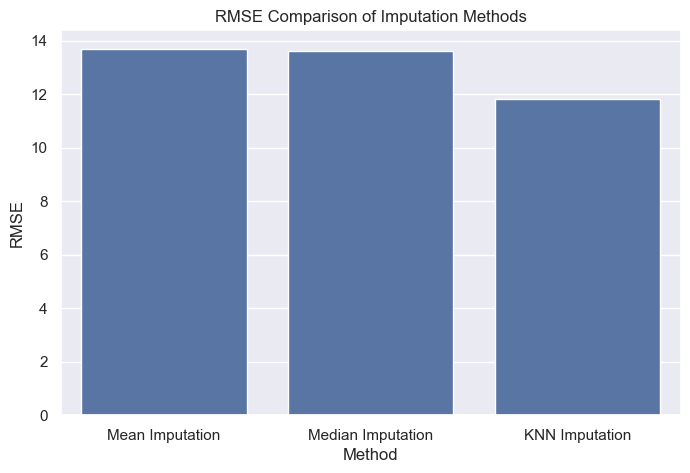

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(x='Method', y='RMSE', data=results)

plt.title("RMSE Comparison of Imputation Methods")

plt.show()

In [44]:
best_method = results.loc[results['RMSE'].idxmin()]

print("Best Imputation Method:")
print(best_method)

Best Imputation Method:
Method    KNN Imputation
RMSE           11.814967
Name: 2, dtype: object


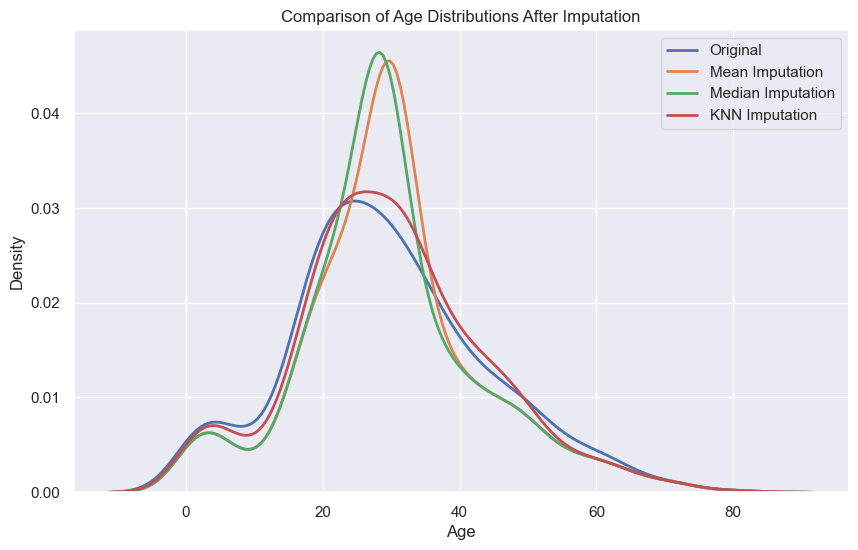

In [65]:
# Compare distributions after imputation

plt.figure(figsize=(10,6))

# Original Age distribution
sns.kdeplot(df["Age"], label="Original", linewidth=2)

# Mean imputed distribution
sns.kdeplot(mean_imputed["Age"], label="Mean Imputation", linewidth=2)

# Median imputed distribution
sns.kdeplot(median_imputed["Age"], label="Median Imputation", linewidth=2)

# KNN imputed distribution
sns.kdeplot(knn_imputed["Age"], label="KNN Imputation", linewidth=2)

plt.title("Comparison of Age Distributions After Imputation")

plt.xlabel("Age")
plt.ylabel("Density")

plt.legend()

plt.show()

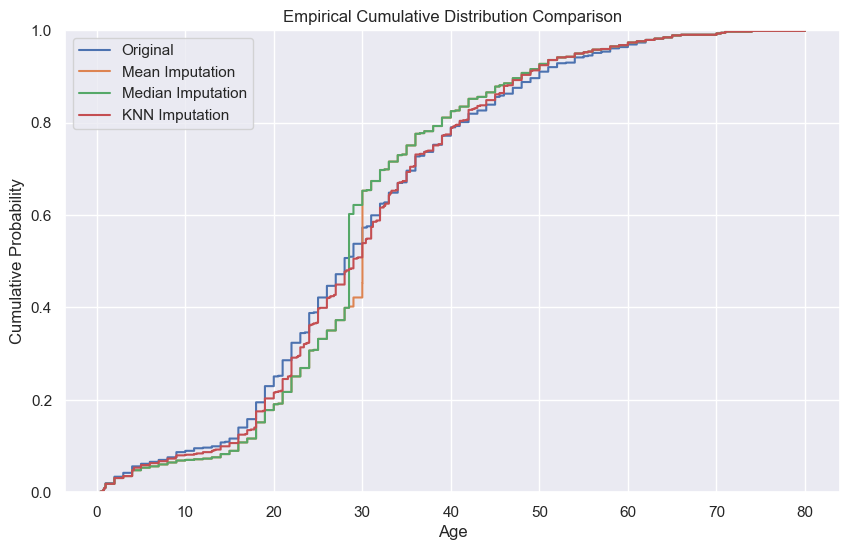

In [69]:
plt.figure(figsize=(10,6))

sns.ecdfplot(df["Age"].dropna(), label="Original")

sns.ecdfplot(mean_imputed["Age"], label="Mean Imputation")

sns.ecdfplot(median_imputed["Age"], label="Median Imputation")

sns.ecdfplot(knn_imputed["Age"], label="KNN Imputation")

plt.title("Empirical Cumulative Distribution Comparison")

plt.xlabel("Age")
plt.ylabel("Cumulative Probability")

plt.legend()

plt.show()

<Axes: ylabel='Age'>

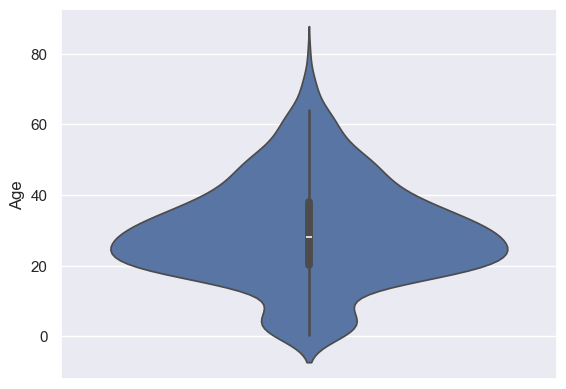

In [71]:
sns.violinplot(data=df["Age"])